# Apple Stock

### Introduction:

We are going to use Apple's stock price.


### Step 1. Import the necessary libraries

In [27]:
import pandas as pd 
import matplotlib.pyplot as plt 

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv)

In [3]:
lnk = 'https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv'
apple = pd.read_csv(lnk)


### Step 3. Assign it to a variable apple

In [4]:
apple.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 4.  Check out the type of the columns

In [5]:
apple.dtypes

Date             str
Open         float64
High         float64
Low          float64
Close        float64
Volume         int64
Adj Close    float64
dtype: object

### Step 5. Transform the Date column as a datetime type

In [6]:
apple.Date = pd.to_datetime(apple.Date, format='%Y-%m-%d')
apple.dtypes

Date         datetime64[us]
Open                float64
High                float64
Low                 float64
Close               float64
Volume                int64
Adj Close           float64
dtype: object

### Step 6.  Set the date as the index

In [7]:
apple = apple.set_index('Date')
apple.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


### Step 7.  Is there any duplicate dates?

In [44]:
apple.index.is_unique

True

### Step 8.  Ops...it seems the index is from the most recent date. Make the first entry the oldest date.

In [17]:
apple = apple.sort_index()
apple.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-12,28.75,28.87,28.75,28.75,117258400,0.45
1980-12-15,27.38,27.38,27.25,27.25,43971200,0.42
1980-12-16,25.37,25.37,25.25,25.25,26432000,0.39
1980-12-17,25.87,26.00,25.87,25.87,21610400,0.40
1980-12-18,26.63,26.75,26.63,26.63,18362400,0.41


### Step 9. Get the last business day of each month

In [46]:
mn = apple.index.min()
mx = apple.index.max()

pd.bdate_range(
    start=mn, 
    end=mx, 
    freq='BME'
).to_list()

[Timestamp('1980-12-31 00:00:00'),
 Timestamp('1981-01-30 00:00:00'),
 Timestamp('1981-02-27 00:00:00'),
 Timestamp('1981-03-31 00:00:00'),
 Timestamp('1981-04-30 00:00:00'),
 Timestamp('1981-05-29 00:00:00'),
 Timestamp('1981-06-30 00:00:00'),
 Timestamp('1981-07-31 00:00:00'),
 Timestamp('1981-08-31 00:00:00'),
 Timestamp('1981-09-30 00:00:00'),
 Timestamp('1981-10-30 00:00:00'),
 Timestamp('1981-11-30 00:00:00'),
 Timestamp('1981-12-31 00:00:00'),
 Timestamp('1982-01-29 00:00:00'),
 Timestamp('1982-02-26 00:00:00'),
 Timestamp('1982-03-31 00:00:00'),
 Timestamp('1982-04-30 00:00:00'),
 Timestamp('1982-05-31 00:00:00'),
 Timestamp('1982-06-30 00:00:00'),
 Timestamp('1982-07-30 00:00:00'),
 Timestamp('1982-08-31 00:00:00'),
 Timestamp('1982-09-30 00:00:00'),
 Timestamp('1982-10-29 00:00:00'),
 Timestamp('1982-11-30 00:00:00'),
 Timestamp('1982-12-31 00:00:00'),
 Timestamp('1983-01-31 00:00:00'),
 Timestamp('1983-02-28 00:00:00'),
 Timestamp('1983-03-31 00:00:00'),
 Timestamp('1983-04-

### Step 10.  What is the difference in days between the first day and the oldest

In [47]:
(mx - mn).days

12261

### Step 11.  How many months in the data we have?

In [26]:
pd.date_range(mn, mx, freq='ME').nunique()

403

### Step 12. Plot the 'Adj Close' value. Set the size of the figure to 13.5 x 9 inches

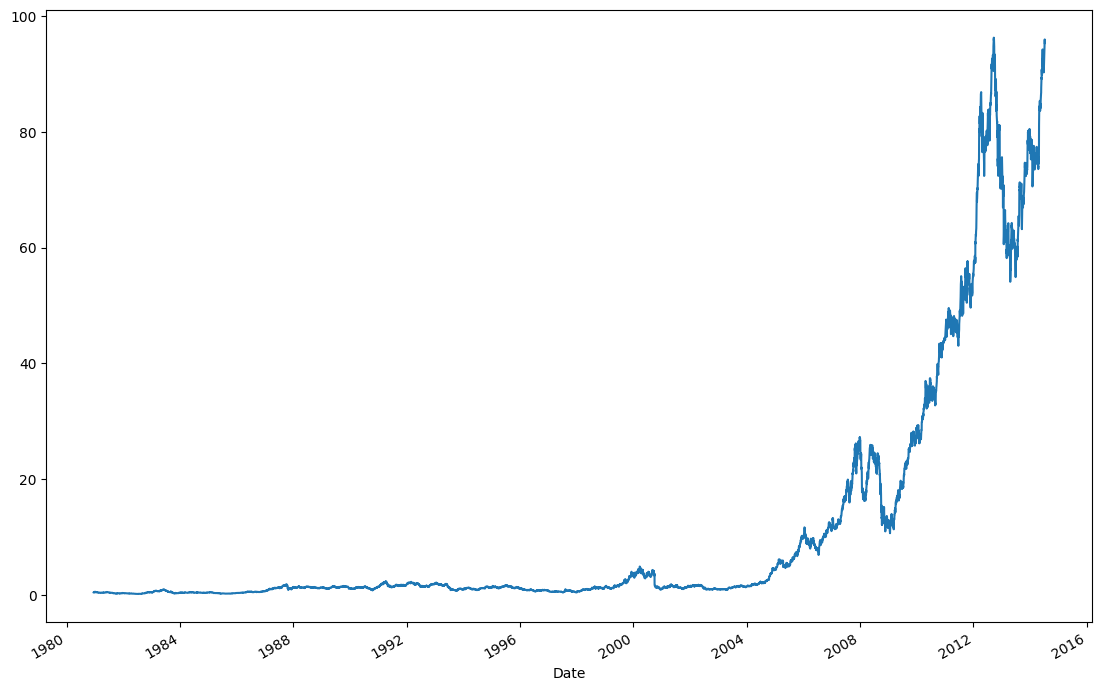

In [48]:
plt.figure(figsize=(13.5, 9))
apple['Adj Close'].plot();

### BONUS: Create your own question and answer it.

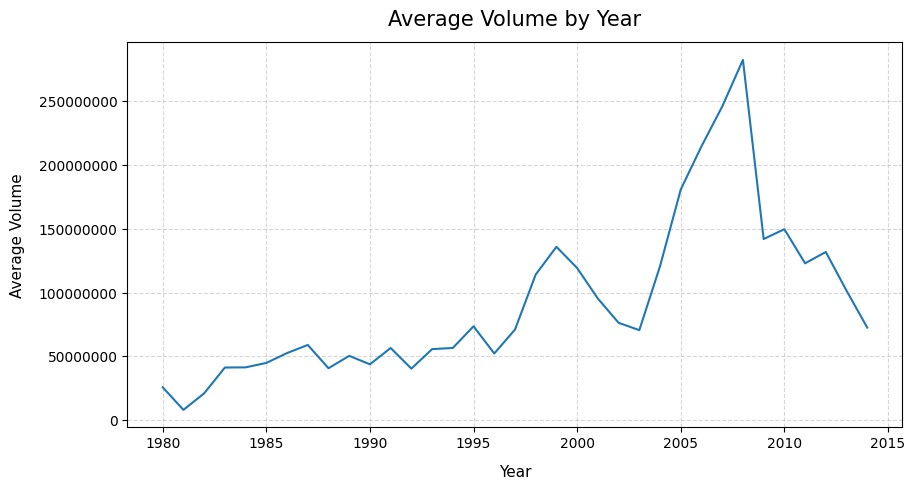

In [ ]:
# finding average volume in every year & creating lineplot

grouped = apple.groupby(lambda date: date.year).Volume.mean()

plt.figure(figsize=(10, 5))
grouped.plot()
plt.ticklabel_format(style='plain')
plt.xlabel('Year', fontsize=11, labelpad=10)
plt.ylabel('Average Volume', fontsize=11, labelpad=10)
plt.title('Average Volume by Year', fontsize=15, pad=12)
plt.grid(alpha=.5, ls='--');